In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path("../data/processed/final_merged_player_data.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(5651, 58)


,draft_year,round,pick,team,hof,position,category,side,college,age,...,rec_Y/R,rec_TD,rec_Y/G,Sk,Solo,Ast,Comb,TFL,Int,PD
0,2000,1,1,CLE,False,DE,DL,D,Penn St.,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000,1,2,WAS,False,LB,LB,D,Penn St.,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000,1,3,WAS,False,T,OL,O,Alabama,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000,1,4,CIN,False,WR,WR,O,Florida St.,23.0,...,17.0,32.0,65.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000,1,5,BAL,False,RB,RB,O,Tennessee,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
print("Top NFL positions:")
print(df["pos_nfl"].value_counts().head(15))

Top NFL positions:
pos_nfl
WR      647
CB      553
RB      403
DT      370
OT      367
S       344
DE      336
OLB     282
TE      280
QB      211
OG      201
ILB     163
LB      129
C       115
EDGE     96
Name: count, dtype: int64


In [3]:
pos_av = (
    df.groupby("pos_nfl")["dr_av"]
    .agg(["count", "mean", "median", "std"])
    .sort_values(by="count", ascending=False)
)

print(pos_av.head(15))

         count       mean  median        std
pos_nfl                                     
WR         647  12.771252     6.0  17.412681
CB         553  11.179024     7.0  13.387973
RB         403  14.498759     8.0  17.537504
DT         370  14.305405     7.0  18.720776
OT         367  19.144414    12.0  20.328003
S          344  13.302326    10.0  14.386639
DE         336  16.598214    10.0  20.487693
OLB        282  16.737589     9.0  20.171205
TE         280   9.021429     4.0  12.965058
QB         211  19.905213     6.0  31.503145
OG         201  16.532338    10.0  18.718178
ILB        163  15.319018     9.0  18.513827
LB         129  10.410853     6.0  10.606316
C          115  19.173913    14.0  20.236436
EDGE        96   7.229167     3.0   9.757566


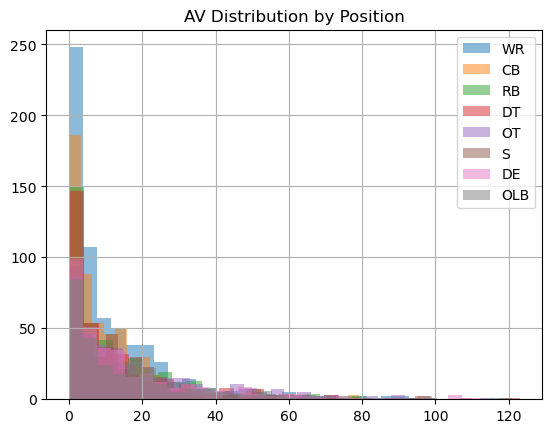

In [4]:
import matplotlib.pyplot as plt

top_positions = df["pos_nfl"].value_counts().head(8).index

for pos in top_positions:
    df[df["pos_nfl"] == pos]["dr_av"].hist(alpha=0.5, bins=30, label=pos)

plt.legend()
plt.title("AV Distribution by Position")
plt.show()

In [5]:
def map_position(pos):
    if pos == "QB":
        return "QB"
    
    elif pos in ["RB", "WR", "TE"]:
        return "SKILL"
    
    elif pos in ["CB", "S", "DB", "LB", "ILB", "OLB", "DT", "DE", "EDGE"]:
        return "DEFENSE"
    
    elif pos in ["OT", "OG", "C"]:
        return "OL"
    
    else:
        return "OTHER"

In [6]:
df["pos_group"] = df["pos_nfl"].apply(map_position)

print(df["pos_group"].value_counts())

pos_group
DEFENSE    2314
SKILL      1330
OTHER      1113
OL          683
QB          211
Name: count, dtype: int64


In [7]:
print(
    df.groupby("pos_group")["dr_av"]
    .agg(["count", "mean", "median", "std"])
)

           count       mean  median        std
pos_group                                     
DEFENSE     2314  13.490925     8.0  16.798574
OL           683  18.380673    12.0  19.859220
OTHER       1113   7.873315     3.0  11.978441
QB           211  19.905213     6.0  31.503145
SKILL       1330  12.505263     6.0  16.718185


In [8]:
qb_features = [
    "qb_Cmp", "qb_Att", "qb_Cmp%", "qb_Yds",
    "qb_TD", "qb_Int", "qb_Y/A", "qb_AY/A", "qb_Y/G"
]

skill_features = [
    "rb_rush_Att", "rb_rush_Yds", "rb_rush_Y_per_Att", "rb_rush_TD",
    "rb_rec_Rec", "rb_rec_Yds", "rb_rec_Y_per_Rec", "rb_rec_TD",
    "rec_Rec", "rec_Yds", "rec_Y/R", "rec_TD", "rec_Y/G"
]

defense_features = [
    "Sk", "Solo", "Ast", "Comb", "TFL",
    "Int", "PD"
]

combine_features = [
    "ht", "wt", "forty", "bench", "vertical",
    "broad_jump", "cone", "shuttle", "age"
]

In [9]:
qb_df = df[df["pos_group"] == "QB"].copy()

qb_df = qb_df[qb_features + combine_features + ["dr_av", "draft_year"]]

qb_df = qb_df.dropna(subset=["qb_Att"])

print("QB:", qb_df.shape)

QB: (176, 20)


In [10]:
skill_df = df[df["pos_group"] == "SKILL"].copy()

skill_df = skill_df[skill_features + combine_features + ["dr_av", "draft_year"]]

skill_df = skill_df.dropna(subset=["rec_Rec", "rb_rush_Att"], how="all")

print("SKILL:", skill_df.shape)

SKILL: (1073, 24)


In [ ]:
def_df = df[df["pos_group"] == "DEFENSE"].copy()

def_df = def_df[defense_features + combine_features + ["dr_av", "draft_year"]]

def_df = def_df.dropna(subset=["Solo", "Sk"], how="all")

print("DEFENSE:", def_df.shape)

DEFENSE: (837, 18)


In [12]:
ol_df = df[df["pos_group"] == "OL"].copy()

ol_df = ol_df[combine_features + ["dr_av", "draft_year"]]

print("OL:", ol_df.shape)

OL: (683, 11)


In [13]:
def fill_numeric(df):
    return df.fillna(df.median(numeric_only=True))

qb_df = fill_numeric(qb_df)
skill_df = fill_numeric(skill_df)
def_df = fill_numeric(def_df)
ol_df = fill_numeric(ol_df)

In [14]:
qb_df.to_csv("../data/processed/qb_model_data.csv", index=False)
skill_df.to_csv("../data/processed/skill_model_data.csv", index=False)
def_df.to_csv("../data/processed/def_model_data.csv", index=False)
ol_df.to_csv("../data/processed/ol_model_data.csv", index=False)

In [15]:
qb_df = pd.read_csv("../data/processed/qb_model_data.csv")
skill_df = pd.read_csv("../data/processed/skill_model_data.csv")
def_df = pd.read_csv("../data/processed/def_model_data.csv")
ol_df = pd.read_csv("../data/processed/ol_model_data.csv")

In [16]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [17]:
def time_split(df, year_col="draft_year", split_year=2018):
    train = df[df[year_col] <= split_year].copy()
    test  = df[df[year_col] > split_year].copy()
    return train, test


def train_rf(df, name):
    train, test = time_split(df)

    # Drop BOTH dr_av and draft_year
    X_train = train.drop(columns=["dr_av", "draft_year"])
    y_train = train["dr_av"]

    X_test = test.drop(columns=["dr_av", "draft_year"])
    y_test = test["dr_av"]

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"\n=== {name} ===")
    print("Train size:", len(train), "Test size:", len(test))
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE:  {mae:.3f}")
    print(f"R²:   {r2:.3f}")

    return {
        "group": name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

In [18]:
results = []

results.append(train_rf(qb_df, "QB"))
results.append(train_rf(skill_df, "SKILL"))
results.append(train_rf(def_df, "DEFENSE"))
results.append(train_rf(ol_df, "OL"))

pd.DataFrame(results)


=== QB ===
Train size: 145 Test size: 31
RMSE: 21.053
MAE:  17.592
R²:   0.287

=== SKILL ===
Train size: 863 Test size: 210
RMSE: 13.912
MAE:  11.320
R²:   -0.000

=== DEFENSE ===
Train size: 694 Test size: 143
RMSE: 13.334
MAE:  10.844
R²:   -0.478

=== OL ===
Train size: 546 Test size: 137
RMSE: 16.723
MAE:  14.661
R²:   -2.269


,group,rmse,mae,r2
0,QB,21.052577,17.591680,0.286511
1,SKILL,13.911808,11.320188,-0.000065
2,DEFENSE,13.333553,10.844233,-0.478225
3,OL,16.722993,14.661024,-2.268976


In [19]:
# Cell: create AV classification labels

def av_to_class(av):
    if av < 5:
        return 0   # low
    elif av < 15:
        return 1   # average
    else:
        return 2   # star

df["av_class"] = df["dr_av"].apply(av_to_class)

print(df["av_class"].value_counts(normalize=True))

av_class
0    0.416210
2    0.296054
1    0.287737
Name: proportion, dtype: float64


In [20]:
# Cell: quantile-based labels 

df["av_class_q"] = pd.qcut(df["dr_av"], q=3, labels=[0,1,2])

print(df["av_class_q"].value_counts())

av_class_q
0    2089
1    1781
2    1781
Name: count, dtype: int64


In [21]:
# Cell: define fine-grained position groups

position_map = {
    "QB": ["QB"],
    "RB": ["RB"],
    "WR": ["WR"],
    "TE": ["TE"],
    "OL": ["OT", "OG", "C"],
    "DL": ["DT", "DE", "EDGE"],
    "LB": ["LB", "ILB", "OLB"],
    "DB": ["CB", "S"]
}

def map_pos_fine(pos):
    for group, positions in position_map.items():
        if pos in positions:
            return group
    return "OTHER"

df["pos_fine"] = df["pos_nfl"].apply(map_pos_fine)

print(df["pos_fine"].value_counts())

pos_fine
OTHER    1154
DB        897
DL        802
OL        683
WR        647
LB        574
RB        403
TE        280
QB        211
Name: count, dtype: int64


In [22]:
# Cell: create datasets per position

datasets = {}

for pos in df["pos_fine"].unique():
    subset = df[df["pos_fine"] == pos].copy()
    
    # drop rows with no AV
    subset = subset.dropna(subset=["dr_av"])
    
    datasets[pos] = subset
    
    print(f"{pos}: {subset.shape}")

DL: (802, 62)
LB: (574, 62)
OL: (683, 62)
WR: (647, 62)
RB: (403, 62)
TE: (280, 62)
DB: (897, 62)
OTHER: (1154, 62)
QB: (211, 62)


In [23]:
# Cell: define feature sets

common_features = [
    "ht", "wt", "forty", "bench", "vertical",
    "broad_jump", "cone", "shuttle", "age"
]

feature_sets = {
    "QB": qb_features + common_features,
    "RB": skill_features + common_features,
    "WR": skill_features + common_features,
    "TE": skill_features + common_features,
    "DL": defense_features + common_features,
    "LB": defense_features + common_features,
    "DB": defense_features + common_features,
    "OL": common_features
}

In [24]:
# Cell: clean + prepare datasets

clean_datasets = {}

for pos, data in datasets.items():
    
    if pos not in feature_sets:
        continue
    
    cols = feature_sets[pos] + ["dr_av", "av_class", "draft_year"]
    
    sub = data[cols].copy()
    
    # fill missing
    sub = sub.fillna(sub.median(numeric_only=True))
    
    clean_datasets[pos] = sub
    
    print(f"{pos}: {sub.shape}")

DL: (802, 19)
LB: (574, 19)
OL: (683, 12)
WR: (647, 25)
RB: (403, 25)
TE: (280, 25)
DB: (897, 19)
QB: (211, 21)


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def train_classifier(df, name):
    
    train, test = time_split(df)
    
    X_train = train.drop(columns=["dr_av", "av_class", "draft_year"])
    y_train = train["av_class"]
    
    X_test = test.drop(columns=["dr_av", "av_class", "draft_year"])
    y_test = test["av_class"]
    
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    
    print(f"\n=== {name} ===")
    print("Train:", len(train), "Test:", len(test))
    print("Accuracy:", round(acc, 3))
    print(classification_report(y_test, preds))
    
    return model

In [26]:
# Cell: run classification models

models = {}

for pos, data in clean_datasets.items():
    if len(data) < 100:
        continue
    
    model = train_classifier(data, pos)
    models[pos] = model


=== DL ===
Train: 620 Test: 182
Accuracy: 0.374
              precision    recall  f1-score   support

           0       0.76      0.37      0.49       112
           1       0.23      0.21      0.22        47
           2       0.20      0.74      0.31        23

    accuracy                           0.37       182
   macro avg       0.40      0.44      0.34       182
weighted avg       0.55      0.37      0.40       182


=== LB ===
Train: 444 Test: 130
Accuracy: 0.308
              precision    recall  f1-score   support

           0       0.46      0.25      0.32        48
           1       0.29      0.08      0.12        50
           2       0.27      0.75      0.39        32

    accuracy                           0.31       130
   macro avg       0.34      0.36      0.28       130
weighted avg       0.35      0.31      0.26       130


=== OL ===
Train: 546 Test: 137
Accuracy: 0.277
              precision    recall  f1-score   support

           0       0.43      0.07   

c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [27]:
# Cell: feature importance

import matplotlib.pyplot as plt

def plot_importance(model, df, name):
    
    features = df.drop(columns=["dr_av", "av_class", "draft_year"]).columns
    importances = model.feature_importances_
    
    idx = np.argsort(importances)[-10:]
    
    plt.figure()
    plt.barh(range(len(idx)), importances[idx])
    plt.yticks(range(len(idx)), features[idx])
    plt.title(f"{name} Feature Importance")
    plt.show()

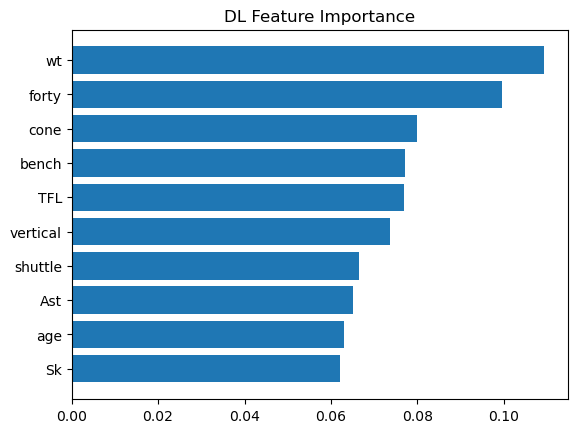

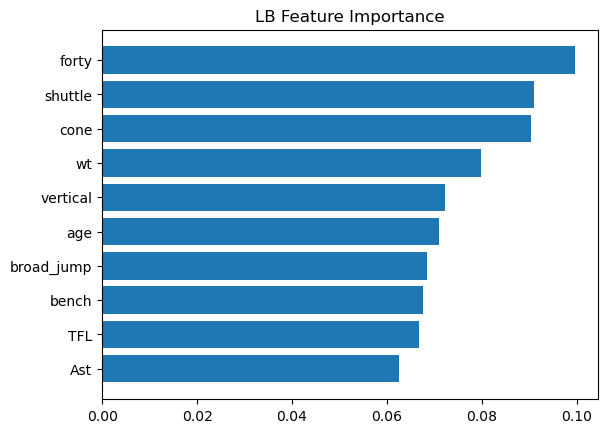

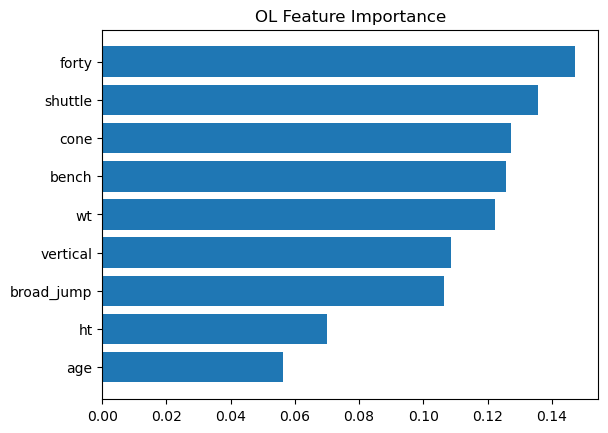

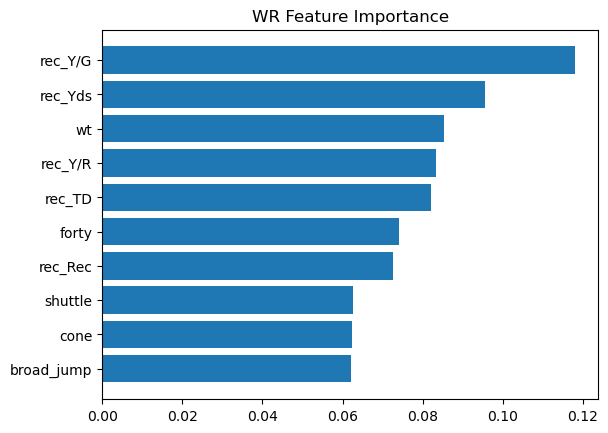

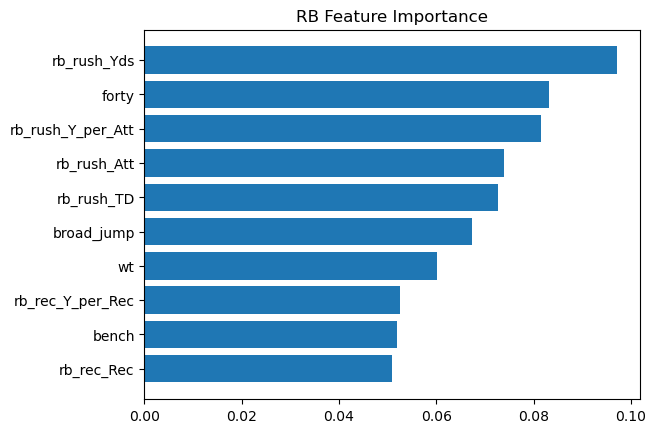

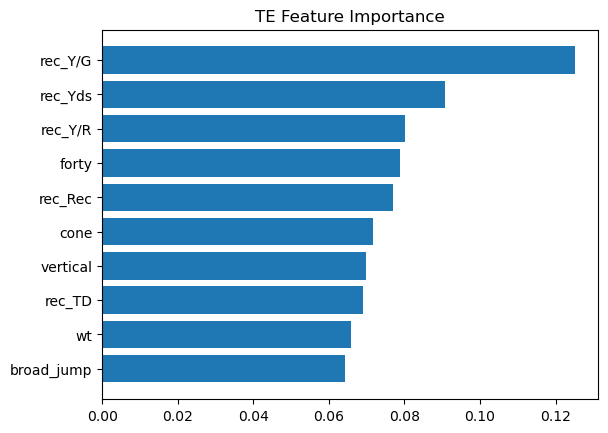

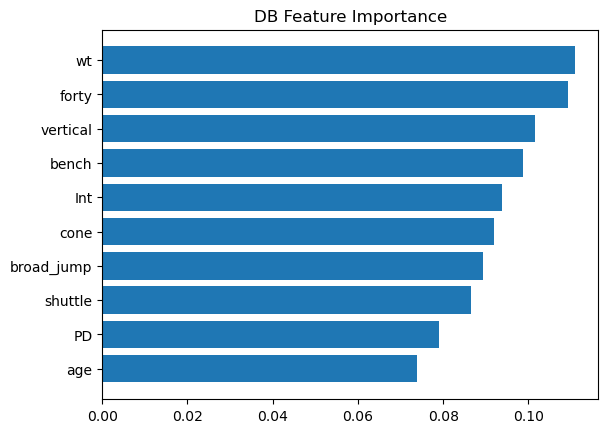

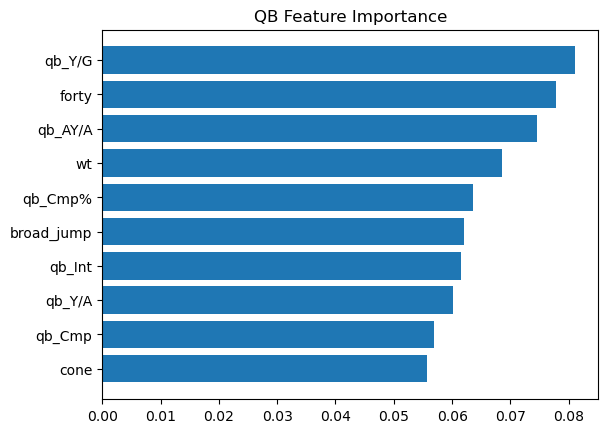

In [28]:
# Cell: visualize feature importance

for pos in models:
    plot_importance(models[pos], clean_datasets[pos], pos)

In [29]:
# Cell: create quantile labels per position

df["av_class_q"] = -1  # initialize

for pos in df["pos_fine"].unique():
    subset_idx = df[df["pos_fine"] == pos].index
    
    # use qcut only if enough data
    if len(subset_idx) > 50:
        df.loc[subset_idx, "av_class_q"] = pd.qcut(
            df.loc[subset_idx, "dr_av"],
            q=3,
            labels=[0, 1, 2],
            duplicates="drop"
        )
        
print(df["av_class_q"].value_counts())

av_class_q
0    2019
1    1833
2    1799
Name: count, dtype: int64


In [30]:
# Cell: rebuild datasets with quantile labels

clean_datasets_q = {}

for pos, data in datasets.items():
    
    if pos not in feature_sets:
        continue
    
    cols = feature_sets[pos] + ["dr_av", "av_class_q", "draft_year"]
    
    sub = data[cols].copy()
    
    # drop rows without labels
    sub = sub[sub["av_class_q"] != -1]
    
    # fill missing
    sub = sub.fillna(sub.median(numeric_only=True))
    
    clean_datasets_q[pos] = sub
    
    print(f"{pos}: {sub.shape}")

DL: (802, 19)
LB: (574, 19)
OL: (683, 12)
WR: (647, 25)
RB: (403, 25)
TE: (280, 25)
DB: (897, 19)
QB: (211, 21)


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def train_classifier_q(df, name):
    
    train, test = time_split(df)
    
    X_train = train.drop(columns=["dr_av", "av_class_q", "draft_year"])
    y_train = train["av_class_q"]
    
    X_test = test.drop(columns=["dr_av", "av_class_q", "draft_year"])
    y_test = test["av_class_q"]
    
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",   # 🔥 important fix
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    
    print(f"\n=== {name} (Quantile) ===")
    print("Train:", len(train), "Test:", len(test))
    print("Accuracy:", round(acc, 3))
    print(classification_report(y_test, preds, zero_division=0))
    
    return model

In [32]:
# Cell: run quantile models

models_q = {}

for pos, data in clean_datasets_q.items():
    if len(data) < 100:
        continue
    
    model = train_classifier_q(data, pos)
    models_q[pos] = model


=== DL (Quantile) ===
Train: 620 Test: 182
Accuracy: 0.401
              precision    recall  f1-score   support

           0       0.65      0.37      0.47        99
           1       0.32      0.29      0.31        58
           2       0.26      0.76      0.39        25

    accuracy                           0.40       182
   macro avg       0.41      0.48      0.39       182
weighted avg       0.49      0.40      0.41       182


=== LB (Quantile) ===
Train: 444 Test: 130
Accuracy: 0.308
              precision    recall  f1-score   support

           0       0.33      0.12      0.18        42
           1       0.33      0.19      0.24        52
           2       0.29      0.69      0.41        36

    accuracy                           0.31       130
   macro avg       0.32      0.34      0.28       130
weighted avg       0.32      0.31      0.27       130


=== OL (Quantile) ===
Train: 546 Test: 137
Accuracy: 0.336
              precision    recall  f1-score   support

   

In [33]:
# Cell: refined feature sets (LESS NOISE)

common_features = [
    "ht", "wt", "forty", "bench", "vertical",
    "broad_jump", "cone", "shuttle", "age"
]

feature_sets_refined = {

    "QB": [
        "qb_Cmp", "qb_Att", "qb_Cmp%", "qb_Yds",
        "qb_TD", "qb_Int", "qb_Y/A", "qb_AY/A", "qb_Y/G"
    ] + common_features,

    "RB": [
        "rb_rush_Att", "rb_rush_Yds", "rb_rush_Y_per_Att", "rb_rush_TD",
        "rb_rec_Rec", "rb_rec_Yds", "rb_rec_Y_per_Rec", "rb_rec_TD"
    ] + common_features,

    "WR": [
        "rec_Rec", "rec_Yds", "rec_Y/R", "rec_TD", "rec_Y/G"
    ] + common_features,

    "TE": [
        "rec_Rec", "rec_Yds", "rec_Y/R", "rec_TD", "rec_Y/G"
    ] + common_features,

    "DL": [
        "Sk", "TFL", "Solo"
    ] + common_features,

    "LB": [
        "Solo", "Ast", "Comb", "TFL"
    ] + common_features,

    "DB": [
        "Int", "PD", "Solo"
    ] + common_features,

    "OL": common_features
}

In [34]:
# Cell: rebuild clean datasets (refined)

clean_datasets_reg = {}

for pos, data in datasets.items():
    
    if pos not in feature_sets_refined:
        continue
    
    cols = feature_sets_refined[pos] + ["dr_av", "draft_year"]
    
    sub = data[cols].copy()
    
    # fill missing
    sub = sub.fillna(sub.median(numeric_only=True))
    
    clean_datasets_reg[pos] = sub
    
    print(f"{pos}: {sub.shape}")

DL: (802, 14)
LB: (574, 15)
OL: (683, 11)
WR: (647, 16)
RB: (403, 19)
TE: (280, 16)
DB: (897, 14)
QB: (211, 20)


In [35]:
# Cell: define models

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),

    "RF": RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),

    "GB": GradientBoostingRegressor(
        n_estimators=200, max_depth=3, random_state=42
    ),

    "HistGB": HistGradientBoostingRegressor(
        max_depth=6, random_state=42
    ),

    "KNN": KNeighborsRegressor(n_neighbors=10),

    "SVR": SVR()
}

In [36]:
# Cell: evaluation function

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    return rmse, mae, r2

In [37]:
# Cell: run all models per position

results_all = []

for pos, df_pos in clean_datasets_reg.items():
    
    if len(df_pos) < 100:
        continue
    
    train, test = time_split(df_pos)
    
    X_train = train.drop(columns=["dr_av", "draft_year"])
    y_train = train["dr_av"]
    
    X_test = test.drop(columns=["dr_av", "draft_year"])
    y_test = test["dr_av"]
    
    print(f"\n===== {pos} =====")
    
    for name, model in models.items():
        
        try:
            rmse, mae, r2 = evaluate_model(
                model, X_train, y_train, X_test, y_test
            )
            
            print(f"{name:10s} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.3f}")
            
            results_all.append({
                "position": pos,
                "model": name,
                "rmse": rmse,
                "mae": mae,
                "r2": r2
            })
            
        except Exception as e:
            print(f"{name} failed:", e)


===== DL =====
Linear     | RMSE: 14.90 | MAE: 12.80 | R²: -2.351
Ridge      | RMSE: 14.69 | MAE: 12.66 | R²: -2.258
RF         | RMSE: 14.20 | MAE: 12.20 | R²: -2.043
ExtraTrees | RMSE: 15.39 | MAE: 12.93 | R²: -2.576
GB         | RMSE: 15.37 | MAE: 12.46 | R²: -2.567
HistGB     | RMSE: 15.87 | MAE: 13.27 | R²: -2.802
KNN        | RMSE: 13.58 | MAE: 11.84 | R²: -1.784
SVR        | RMSE: 8.55 | MAE: 7.04 | R²: -0.103

===== LB =====
Linear     | RMSE: 13.34 | MAE: 11.50 | R²: -0.729
Ridge      | RMSE: 13.30 | MAE: 11.44 | R²: -0.719
RF         | RMSE: 13.19 | MAE: 11.40 | R²: -0.690
ExtraTrees | RMSE: 13.00 | MAE: 10.98 | R²: -0.642
GB         | RMSE: 12.97 | MAE: 10.82 | R²: -0.634
HistGB     | RMSE: 12.64 | MAE: 10.50 | R²: -0.551
KNN        | RMSE: 13.76 | MAE: 11.24 | R²: -0.838
SVR        | RMSE: 10.23 | MAE: 7.45 | R²: -0.017

===== OL =====
Linear     | RMSE: 16.10 | MAE: 14.29 | R²: -2.031
Ridge      | RMSE: 16.06 | MAE: 14.25 | R²: -2.014
RF         | RMSE: 16.72 | MAE: 14.66

In [38]:
# Cell: best model per position

results_df = pd.DataFrame(results_all)

best_models = (
    results_df.sort_values(by="rmse")
    .groupby("position")
    .first()
    .reset_index()
)

print("\n=== BEST MODELS (by RMSE) ===")
print(best_models)


=== BEST MODELS (by RMSE) ===
  position  model       rmse        mae        r2
0       DB    SVR   8.621390   6.681314 -0.002204
1       DL    SVR   8.547665   7.038273 -0.102731
2       LB    SVR  10.232549   7.451565 -0.017047
3       OL    SVR   9.601728   8.241589 -0.077662
4       QB     RF  17.047866  13.710137  0.294901
5       RB    SVR  11.873728   9.016037 -0.041186
6       TE    SVR   7.034330   5.265255  0.030003
7       WR  Ridge  12.871412  10.254101  0.076585


In [39]:
# Cell: combined score

results_df["score"] = (
    results_df["rmse"] * 0.5 +
    results_df["mae"] * 0.3 -
    results_df["r2"] * 10   # reward higher R²
)

best_combined = (
    results_df.sort_values(by="score")
    .groupby("position")
    .first()
    .reset_index()
)

print("\n=== BEST MODELS (combined score) ===")
print(best_combined)


=== BEST MODELS (combined score) ===
  position  model       rmse        mae        r2     score
0       DB    SVR   8.621390   6.681314 -0.002204  6.337129
1       DL    SVR   8.547665   7.038273 -0.102731  7.412626
2       LB    SVR  10.232549   7.451565 -0.017047  7.522216
3       OL    SVR   9.601728   8.241589 -0.077662  8.049960
4       QB     RF  17.047866  13.710137  0.294901  9.687962
5       RB    SVR  11.873728   9.016037 -0.041186  9.053534
6       TE    SVR   7.034330   5.265255  0.030003  4.796707
7       WR  Ridge  12.871412  10.254101  0.076585  8.746082


In [40]:
# Cell: classification evaluation metrics

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, preds, average="weighted", zero_division=0)
    
    precision_macro = precision_score(y_test, preds, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, preds, average="macro", zero_division=0)
    
    # important: star detection (class 2)
    recall_star = recall_score(y_test, preds, labels=[2], average="macro", zero_division=0)
    
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "recall_star": recall_star
    }

In [41]:
# Cell: sklearn classification models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

models_clf = {

    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    
    "RF": RandomForestClassifier(
        n_estimators=200, max_depth=8,
        class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    
    "GB": GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "HistGB": HistGradientBoostingClassifier(
        max_depth=8,
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(n_neighbors=10),
    
    "NaiveBayes": GaussianNB(),
    
    "SVC": SVC(
        kernel="rbf",
        class_weight="balanced"
    )
}

In [42]:
# Cell: optional advanced models

advanced_models = {}

try:
    import xgboost as xgb
    advanced_models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
except:
    print("XGBoost not available")



try:
    from catboost import CatBoostClassifier
    advanced_models["CatBoost"] = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        verbose=0
    )
except:
    print("CatBoost not available")

# merge
models_clf.update(advanced_models)

In [43]:
# Cell: run classification models

results_clf = []

for pos, df_pos in clean_datasets_q.items():
    
    if len(df_pos) < 100:
        continue
    
    train, test = time_split(df_pos)
    
    X_train = train.drop(columns=["dr_av", "av_class_q", "draft_year"])
    y_train = train["av_class_q"]
    
    X_test = test.drop(columns=["dr_av", "av_class_q", "draft_year"])
    y_test = test["av_class_q"]
    
    print(f"\n===== {pos} =====")
    
    for name, model in models_clf.items():
        
        try:
            metrics = evaluate_classifier(
                model, X_train, y_train, X_test, y_test
            )
            
            print(f"{name:12s} | "
                  f"Acc: {metrics['accuracy']:.3f} | "
                  f"F1_macro: {metrics['f1_macro']:.3f} | "
                  f"StarRecall: {metrics['recall_star']:.3f}")
            
            results_clf.append({
                "position": pos,
                "model": name,
                **metrics
            })
            
        except Exception as e:
            print(f"{name} failed:", e)


===== DL =====
Logistic     | Acc: 0.412 | F1_macro: 0.353 | StarRecall: 0.720


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RF           | Acc: 0.423 | F1_macro: 0.409 | StarRecall: 0.800
ExtraTrees   | Acc: 0.379 | F1_macro: 0.369 | StarRecall: 0.680
GB           | Acc: 0.313 | F1_macro: 0.309 | StarRecall: 0.520
HistGB       | Acc: 0.335 | F1_macro: 0.328 | StarRecall: 0.520
KNN          | Acc: 0.341 | F1_macro: 0.296 | StarRecall: 0.320
NaiveBayes   | Acc: 0.549 | F1_macro: 0.261 | StarRecall: 0.040
SVC          | Acc: 0.412 | F1_macro: 0.305 | StarRecall: 0.080
XGBoost      | Acc: 0.341 | F1_macro: 0.332 | StarRecall: 0.520
CatBoost     | Acc: 0.346 | F1_macro: 0.335 | StarRecall: 0.680

===== LB =====
Logistic     | Acc: 0.392 | F1_macro: 0.388 | StarRecall: 0.611


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RF           | Acc: 0.323 | F1_macro: 0.294 | StarRecall: 0.694
ExtraTrees   | Acc: 0.323 | F1_macro: 0.291 | StarRecall: 0.750
GB           | Acc: 0.338 | F1_macro: 0.323 | StarRecall: 0.611
HistGB       | Acc: 0.323 | F1_macro: 0.294 | StarRecall: 0.694
KNN          | Acc: 0.285 | F1_macro: 0.286 | StarRecall: 0.417
NaiveBayes   | Acc: 0.269 | F1_macro: 0.151 | StarRecall: 0.944
SVC          | Acc: 0.392 | F1_macro: 0.354 | StarRecall: 0.278
XGBoost      | Acc: 0.323 | F1_macro: 0.305 | StarRecall: 0.639
CatBoost     | Acc: 0.331 | F1_macro: 0.306 | StarRecall: 0.694

===== OL =====
Logistic     | Acc: 0.431 | F1_macro: 0.423 | StarRecall: 0.674


...

RF           | Acc: 0.422 | F1_macro: 0.391 | StarRecall: 0.533
ExtraTrees   | Acc: 0.482 | F1_macro: 0.409 | StarRecall: 0.400
GB           | Acc: 0.434 | F1_macro: 0.391 | StarRecall: 0.333
HistGB       | Acc: 0.325 | F1_macro: 0.316 | StarRecall: 0.333
KNN          | Acc: 0.458 | F1_macro: 0.319 | StarRecall: 0.067
NaiveBayes   | Acc: 0.398 | F1_macro: 0.390 | StarRecall: 0.400
SVC          | Acc: 0.349 | F1_macro: 0.340 | StarRecall: 0.333
XGBoost      | Acc: 0.349 | F1_macro: 0.330 | StarRecall: 0.333
CatBoost     | Acc: 0.434 | F1_macro: 0.369 | StarRecall: 0.333

===== DB =====


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic     | Acc: 0.415 | F1_macro: 0.416 | StarRecall: 0.596
RF           | Acc: 0.380 | F1_macro: 0.369 | StarRecall: 0.442
ExtraTrees   | Acc: 0.356 | F1_macro: 0.346 | StarRecall: 0.365
GB           | Acc: 0.385 | F1_macro: 0.371 | StarRecall: 0.346
HistGB       | Acc: 0.390 | F1_macro: 0.381 | StarRecall: 0.404
KNN          | Acc: 0.351 | F1_macro: 0.331 | StarRecall: 0.231
NaiveBayes   | Acc: 0.341 | F1_macro: 0.170 | StarRecall: 0.000
SVC          | Acc: 0.361 | F1_macro: 0.220 | StarRecall: 0.077
XGBoost      | Acc: 0.395 | F1_macro: 0.395 | StarRecall: 0.423
CatBoost     | Acc: 0.385 | F1_macro: 0.374 | StarRecall: 0.346

===== QB =====
Logistic     | Acc: 0.450 | F1_macro: 0.374 | StarRecall: 0.474


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RF           | Acc: 0.417 | F1_macro: 0.314 | StarRecall: 0.421
ExtraTrees   | Acc: 0.467 | F1_macro: 0.384 | StarRecall: 0.526
GB           | Acc: 0.400 | F1_macro: 0.347 | StarRecall: 0.474
HistGB       | Acc: 0.367 | F1_macro: 0.280 | StarRecall: 0.263
KNN          | Acc: 0.383 | F1_macro: 0.281 | StarRecall: 0.158
NaiveBayes   | Acc: 0.317 | F1_macro: 0.264 | StarRecall: 0.684
SVC          | Acc: 0.350 | F1_macro: 0.266 | StarRecall: 0.737
XGBoost      | Acc: 0.450 | F1_macro: 0.343 | StarRecall: 0.421
CatBoost     | Acc: 0.433 | F1_macro: 0.329 | StarRecall: 0.474


In [44]:
# Cell: best models by F1_macro

results_df_clf = pd.DataFrame(results_clf)

best_f1 = (
    results_df_clf.sort_values(by="f1_macro", ascending=False)
    .groupby("position")
    .first()
    .reset_index()
)

print("\n=== BEST MODELS (F1_macro) ===")
print(best_f1[["position", "model", "accuracy", "f1_macro", "recall_star"]])


=== BEST MODELS (F1_macro) ===
  position       model  accuracy  f1_macro  recall_star
0       DB    Logistic  0.414634  0.416171     0.596154
1       DL          RF  0.423077  0.409376     0.800000
2       LB    Logistic  0.392308  0.388477     0.611111
3       OL    Logistic  0.430657  0.422995     0.674419
4       QB  ExtraTrees  0.466667  0.384166     0.526316
5       RB    Logistic  0.364407  0.350244     0.545455
6       TE  ExtraTrees  0.481928  0.409035     0.400000
7       WR    Logistic  0.443850  0.441232     0.395833


In [45]:
# Cell: best models for star detection

best_star = (
    results_df_clf.sort_values(by="recall_star", ascending=False)
    .groupby("position")
    .first()
    .reset_index()
)

print("\n=== BEST MODELS (STAR RECALL) ===")
print(best_star[["position", "model", "accuracy", "f1_macro", "recall_star"]])


=== BEST MODELS (STAR RECALL) ===
  position       model  accuracy  f1_macro  recall_star
0       DB    Logistic  0.414634  0.416171     0.596154
1       DL          RF  0.423077  0.409376     0.800000
2       LB  NaiveBayes  0.269231  0.151181     0.944444
3       OL  NaiveBayes  0.328467  0.224058     0.930233
4       QB         SVC  0.350000  0.266397     0.736842
5       RB  NaiveBayes  0.364407  0.282051     0.727273
6       TE    Logistic  0.409639  0.406340     0.533333
7       WR  ExtraTrees  0.443850  0.416101     0.437500


In [46]:
# Cell: combined score

results_df_clf["score"] = (
    results_df_clf["f1_macro"] * 0.5 +
    results_df_clf["accuracy"] * 0.2 +
    results_df_clf["recall_star"] * 0.3
)

best_combined = (
    results_df_clf.sort_values(by="score", ascending=False)
    .groupby("position")
    .first()
    .reset_index()
)

print("\n=== BEST MODELS (COMBINED) ===")
print(best_combined[["position", "model", "accuracy", "f1_macro", "recall_star"]])


=== BEST MODELS (COMBINED) ===
  position       model  accuracy  f1_macro  recall_star
0       DB    Logistic  0.414634  0.416171     0.596154
1       DL          RF  0.423077  0.409376     0.800000
2       LB    Logistic  0.392308  0.388477     0.611111
3       OL    Logistic  0.430657  0.422995     0.674419
4       QB  ExtraTrees  0.466667  0.384166     0.526316
5       RB  ExtraTrees  0.364407  0.334668     0.727273
6       TE    Logistic  0.409639  0.406340     0.533333
7       WR    Logistic  0.443850  0.441232     0.395833


In [47]:
# Cell: shared evaluation + models

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    return {
        "accuracy": accuracy_score(y_test, preds),
        "f1_macro": f1_score(y_test, preds, average="macro", zero_division=0),
        "precision_macro": precision_score(y_test, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, preds, average="macro", zero_division=0),
        "recall_star": recall_score(y_test, preds, pos_label=1 if len(set(y_test))==2 else 2, average="binary" if len(set(y_test))==2 else "macro", zero_division=0)
    }


# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

models_clf = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RF": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "GB": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "HistGB": HistGradientBoostingClassifier(max_depth=8, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=10),
    "NaiveBayes": GaussianNB(),
    "SVC": SVC(kernel="rbf", class_weight="balanced")
}

# optional advanced
try:
    import xgboost as xgb
    models_clf["XGBoost"] = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric="mlogloss")
except:
    pass

try:
    from catboost import CatBoostClassifier
    models_clf["CatBoost"] = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1, verbose=0)
except:
    pass

In [48]:
# Cell: binary labels (top ~30% = star)

df["star"] = 0

for pos in df["pos_fine"].unique():
    idx = df[df["pos_fine"] == pos].index
    
    if len(idx) > 50:
        threshold = df.loc[idx, "dr_av"].quantile(0.7)
        df.loc[idx, "star"] = (df.loc[idx, "dr_av"] >= threshold).astype(int)

print(df["star"].value_counts())

star
0    3894
1    1757
Name: count, dtype: int64


In [49]:
# Cell: binary datasets (FIXED)

datasets_bin = {}

for pos in df["pos_fine"].unique():
    
    data = df[df["pos_fine"] == pos].copy()   # 🔥 FIX: use df directly
    
    if pos not in feature_sets_refined:
        continue
    
    cols = feature_sets_refined[pos] + ["star", "draft_year"]
    
    # only keep columns that actually exist
    cols = [c for c in cols if c in data.columns]
    
    sub = data[cols].copy()
    
    sub = sub.dropna(subset=["star"])
    sub = sub.fillna(sub.median(numeric_only=True))
    
    datasets_bin[pos] = sub
    
    print(f"{pos}: {sub.shape}")

DL: (802, 14)
LB: (574, 15)
OL: (683, 11)
WR: (647, 16)
RB: (403, 19)
TE: (280, 16)
DB: (897, 14)
QB: (211, 20)


In [50]:
# Cell: binary benchmarking

results_bin = []

for pos, df_pos in datasets_bin.items():
    
    if len(df_pos) < 100:
        continue
    
    train, test = time_split(df_pos)
    
    X_train = train.drop(columns=["star", "draft_year"])
    y_train = train["star"]
    
    X_test = test.drop(columns=["star", "draft_year"])
    y_test = test["star"]
    
    print(f"\n===== {pos} (Binary) =====")
    
    for name, model in models_clf.items():
        try:
            metrics = evaluate_classifier(model, X_train, y_train, X_test, y_test)
            
            results_bin.append({
                "position": pos,
                "model": name,
                **metrics
            })
            
        except:
            pass

results_bin_df = pd.DataFrame(results_bin)

# BEST (F1)
best_bin = (
    results_bin_df.sort_values(by="f1_macro", ascending=False)
    .groupby("position")
    .first()
    .reset_index()
)

print("\n=== BINARY BEST MODELS ===")
print(best_bin[["position","model","accuracy","f1_macro","recall_star"]])


===== DL (Binary) =====

===== LB (Binary) =====


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== OL (Binary) =====

===== WR (Binary) =====


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== RB (Binary) =====


...


===== DB (Binary) =====


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== QB (Binary) =====


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== BINARY BEST MODELS ===
  position       model  accuracy  f1_macro  recall_star
0       DB         SVC  0.629268  0.552299     0.423077
1       DL  NaiveBayes  0.780220  0.620833     0.521739
2       LB          GB  0.723077  0.579288     0.346154
3       OL  ExtraTrees  0.715328  0.588779     0.550000
4       QB          GB  0.750000  0.715100     0.666667
5       RB  ExtraTrees  0.762712  0.594502     0.280000
6       TE         SVC  0.759036  0.645299     0.500000
7       WR    Logistic  0.657754  0.596221     0.520833


In [51]:
# Cell: quantile labels per position

df["av_class_q"] = -1

for pos in df["pos_fine"].unique():
    idx = df[df["pos_fine"] == pos].index
    
    if len(idx) > 50:
        df.loc[idx, "av_class_q"] = pd.qcut(
            df.loc[idx, "dr_av"],
            q=3,
            labels=[0,1,2],
            duplicates="drop"
        )

print(df["av_class_q"].value_counts())

av_class_q
0    2019
1    1833
2    1799
Name: count, dtype: int64


In [52]:
# Cell: quantile datasets

datasets_q = {}

for pos, data in datasets.items():
    
    if pos not in feature_sets_refined:
        continue
    
    cols = feature_sets_refined[pos] + ["av_class_q", "draft_year"]
    
    sub = data[cols].copy()
    
    sub = sub[sub["av_class_q"] != -1]
    sub = sub.fillna(sub.median(numeric_only=True))
    
    datasets_q[pos] = sub
    
    print(f"{pos}: {sub.shape}")

DL: (802, 14)
LB: (574, 15)
OL: (683, 11)
WR: (647, 16)
RB: (403, 19)
TE: (280, 16)
DB: (897, 14)
QB: (211, 20)


In [53]:
# Cell: quantile benchmarking

results_q = []

for pos, df_pos in datasets_q.items():
    
    if len(df_pos) < 100:
        continue
    
    train, test = time_split(df_pos)
    
    X_train = train.drop(columns=["av_class_q", "draft_year"])
    y_train = train["av_class_q"]
    
    X_test = test.drop(columns=["av_class_q", "draft_year"])
    y_test = test["av_class_q"]
    
    print(f"\n===== {pos} (Quantile) =====")
    
    for name, model in models_clf.items():
        try:
            metrics = evaluate_classifier(model, X_train, y_train, X_test, y_test)
            
            results_q.append({
                "position": pos,
                "model": name,
                **metrics
            })
            
        except:
            pass

results_q_df = pd.DataFrame(results_q)

# BEST (F1)
best_q = (
    results_q_df.sort_values(by="f1_macro", ascending=False)
    .groupby("position")
    .first()
    .reset_index()
)

print("\n=== QUANTILE BEST MODELS ===")
print(best_q[["position","model","accuracy","f1_macro","recall_star"]])


===== DL (Quantile) =====


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: 


===== LB (Quantile) =====


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2)


===== OL (Quantile) =====


...

c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: 


===== QB (Quantile) =====


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2)


=== QUANTILE BEST MODELS ===
  position       model  accuracy  f1_macro  recall_star
0       DB    Logistic  0.434146  0.434179     0.458224
1       DL  NaiveBayes  0.390110  0.379762     0.453707
2       LB    Logistic  0.400000  0.397865     0.421958
3       OL    Logistic  0.430657  0.422995     0.438481
4       QB  ExtraTrees  0.466667  0.384166     0.431158
5       RB    Logistic  0.406780  0.399651     0.404463
6       TE          RF  0.445783  0.393881     0.408669
7       WR    Logistic  0.475936  0.469862     0.471396


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\metrics\_classification.py:1784: UserWarning: Note that pos_label (set to 2) is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
